<a href="https://colab.research.google.com/github/igorfurtadobraga-afk/PIB_IBC_br/blob/main/CP_PIB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ANO_MES
0  01-2004
1  02-2004
2  03-2004
3  04-2004
4  05-2004
   ano_mes
0  01-2003
1  02-2003
2  03-2003
3  04-2003
4  05-2003
   Unnamed: 0  ANO_MES     PIB     BRL     BRP     BRT     SLP     SPP  \
0           1  01-2004  103.09  109.19  108.67  109.08  102.84  114.27   
1           2  02-2004  102.05   95.65  104.52   97.63   90.76  109.83   
2           3  03-2004  110.43   91.69  125.53   99.26   89.78  133.24   
3           4  04-2004  106.77   95.36  118.34  100.49   94.58  123.55   
4           5  05-2004  108.08   92.47  121.49   98.96   91.34  128.32   

      SPT     PRL  ...  IBC-Br Services  IBC-Br Taxes  IBC-Br ex-Agriculture  \
0  105.38  127.49  ...         66.65000      65.34043               70.68902   
1   94.99   96.60  ...         65.76559      62.40341               69.13765   
2   99.43   83.79  ...         70.10735      74.61129               76.58056   
3  101.02   91.79  ...         68.77285      70.90561               74.07663   
4   99.55   85.73  ... 

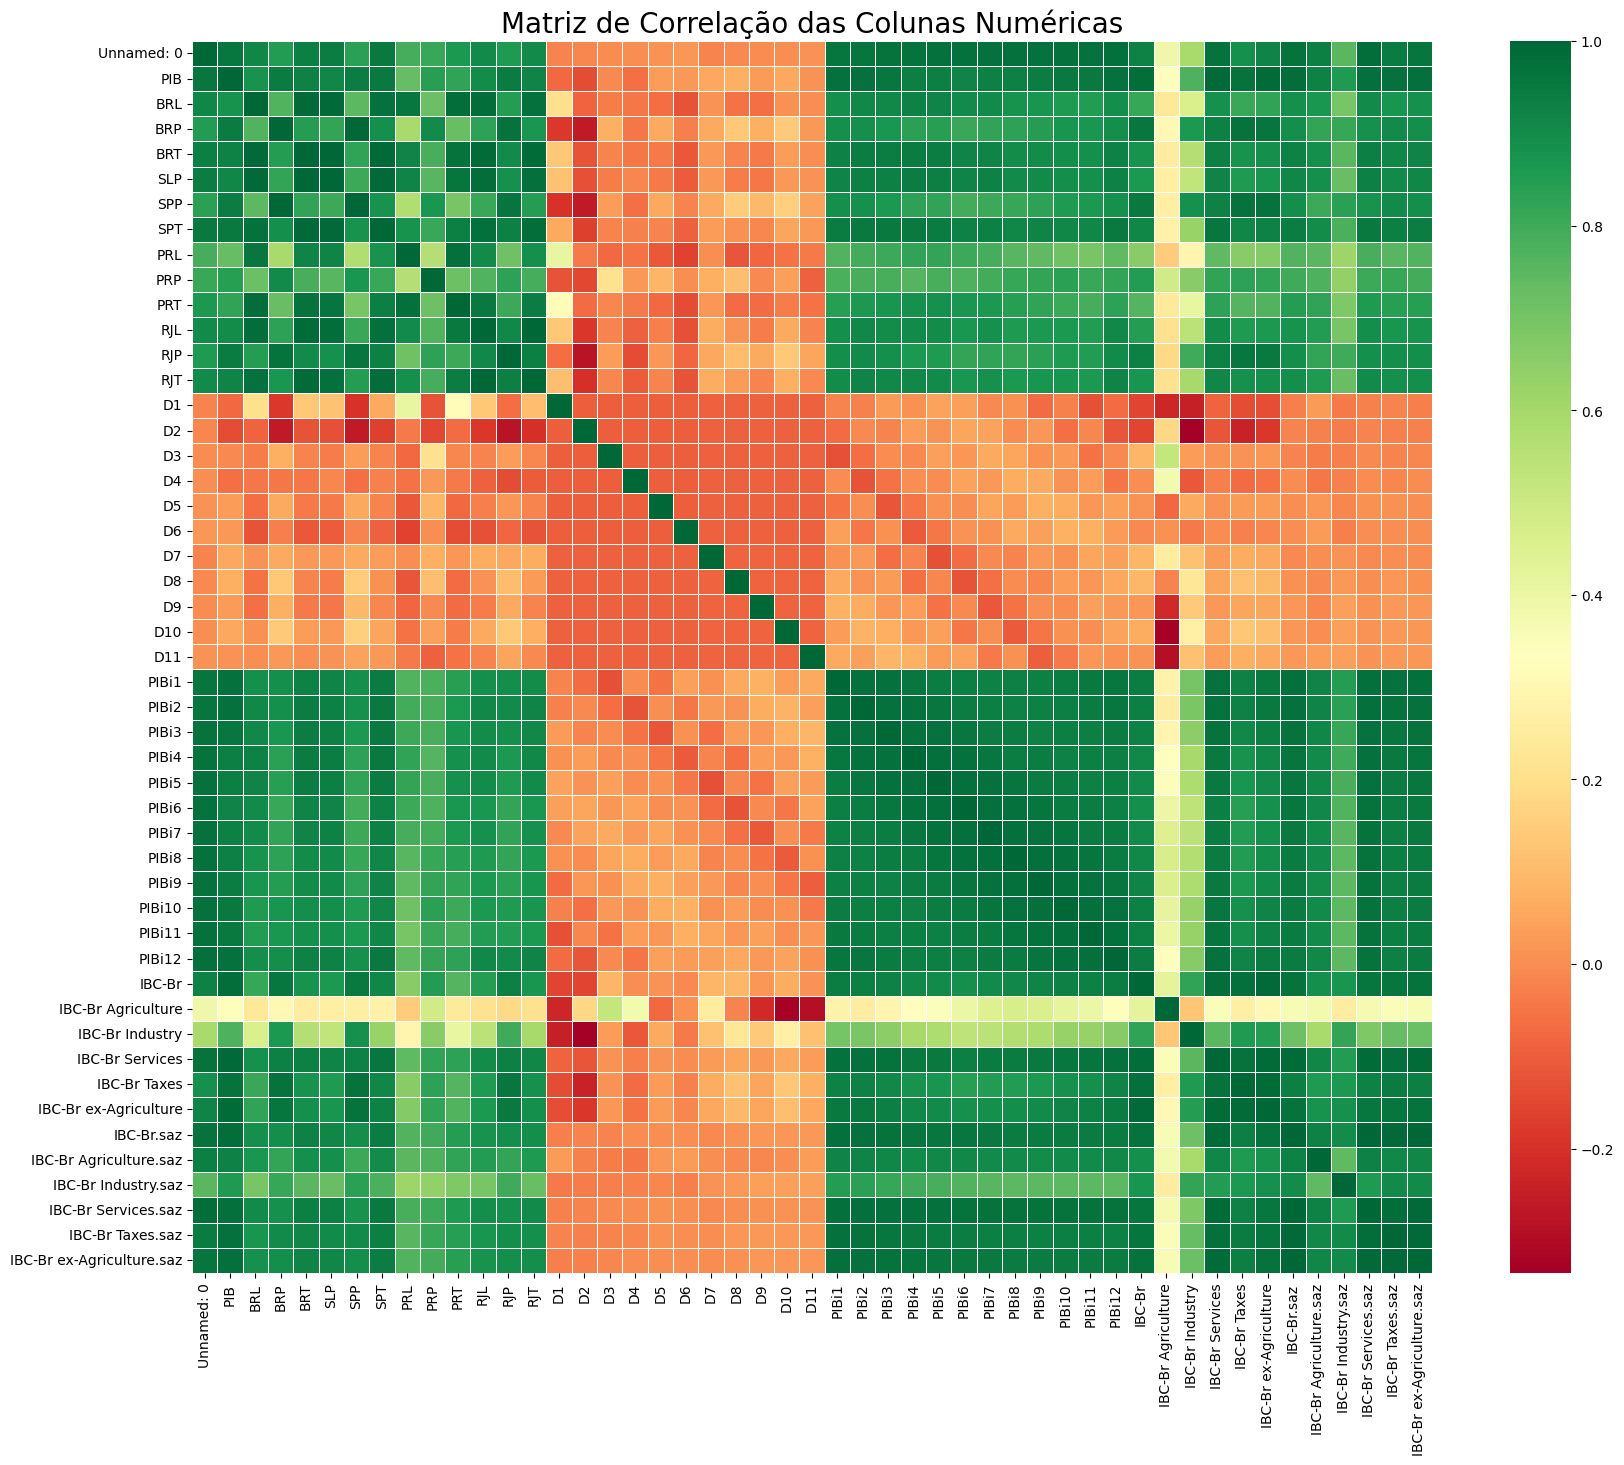

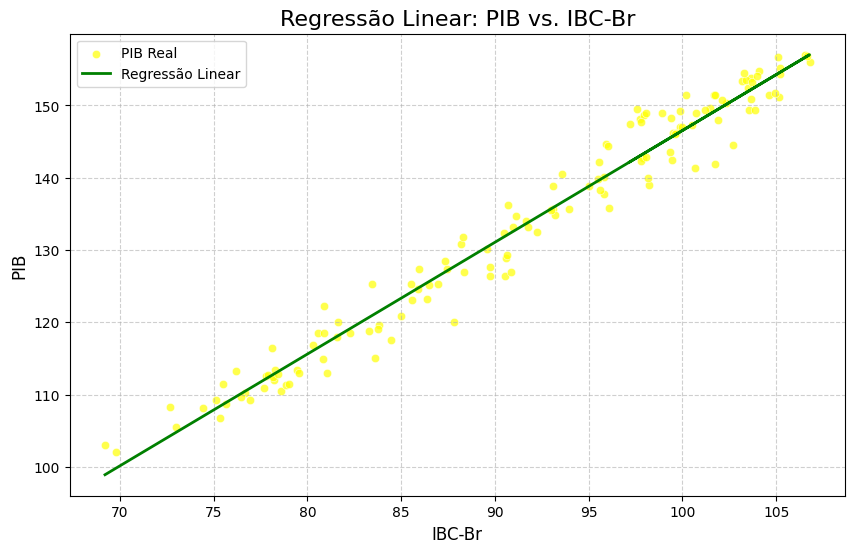

Coeficiente: 1.55
Intercepto: -8.09
R²: 0.97


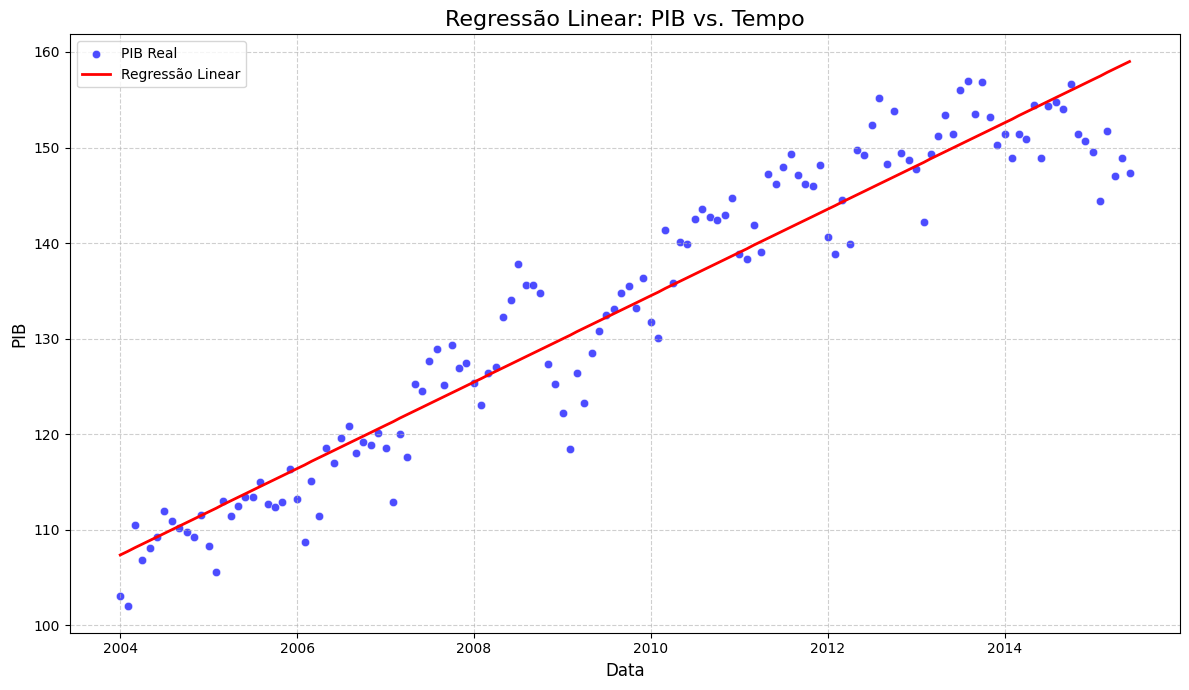

Coeficiente: 0.38
Intercepto: 107.34
R²: 0.92


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# --- Carregamento e Pré-processamento ---

# Carrega o dataset do PIB
df = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')

# Converte abreviações de meses do português para inglês
month_mapping = {
    'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
    'mai': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
    'set': 'Sep', 'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'
}
df['ANO_MES'] = df['ANO_MES'].str[:3].map(month_mapping) + df['ANO_MES'].str[3:]

# Converte ANO_MES para datetime e formata como 'MM-YYYY'
df['ANO_MES_datetime'] = pd.to_datetime(df['ANO_MES'], format='%b/%y')
df['ANO_MES'] = df['ANO_MES_datetime'].dt.strftime('%m-%Y')
print(df[['ANO_MES']].head())

# Carrega o dataset IBC-Br e formata a coluna de data
df_ibc_br = pd.read_excel("/content/IBC-Br_todas_publicacoes.xlsx")
df_ibc_br['ano_mes_datetime'] = pd.to_datetime(df_ibc_br['ano_mes'])
df_ibc_br['ano_mes'] = df_ibc_br['ano_mes_datetime'].dt.strftime('%m-%Y')
print(df_ibc_br[['ano_mes']].head())

# Une os dois datasets pela coluna de data
merged_df = pd.merge(df, df_ibc_br, left_on='ANO_MES', right_on='ano_mes', how='left')
print(merged_df.head())

# Renomeia colunas duplicadas (sufixo '.1' → '.saz')
rename_mapping = {col: col.replace('.1', '.saz') for col in merged_df.columns if col.endswith('.1')}
merged_df = merged_df.rename(columns=rename_mapping)

# Arredonda todas as colunas numéricas para 2 casas decimais
numeric_cols = merged_df.select_dtypes(include=['number']).columns
merged_df[numeric_cols] = merged_df[numeric_cols].round(2)

print(merged_df.head(10))


# --- Análise de Correlação ---

# Calcula e plota a matriz de correlação entre variáveis numéricas
correlation_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='RdYlGn', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Colunas Numéricas', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# --- Regressão Linear: PIB vs. IBC-Br ---

# Treina o modelo e plota a linha de regressão
X_ibc_br = merged_df['IBC-Br'].values.reshape(-1, 1)
y_pib = merged_df['PIB'].values

model_ibc_br = LinearRegression()
model_ibc_br.fit(X_ibc_br, y_pib)
y_pred_ibc_br = model_ibc_br.predict(X_ibc_br)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_ibc_br.flatten(), y=y_pib, color='yellow', label='PIB Real', alpha=0.7)
plt.plot(X_ibc_br.flatten(), y_pred_ibc_br, color='green', label='Regressão Linear', linewidth=2)
plt.title('Regressão Linear: PIB vs. IBC-Br', fontsize=16)
plt.xlabel('IBC-Br', fontsize=12)
plt.ylabel('PIB', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Coeficiente: {model_ibc_br.coef_[0]:.2f}")
print(f"Intercepto: {model_ibc_br.intercept_:.2f}")
print(f"R²: {model_ibc_br.score(X_ibc_br, y_pib):.2f}")


# --- Regressão Linear: PIB vs. Tempo ---

# Cria variável numérica de tempo (meses desde o início)
merged_df['ANO_MES_datetime'] = pd.to_datetime(merged_df['ANO_MES'], format='%m-%Y')
first_date = merged_df['ANO_MES_datetime'].min()
merged_df['ANO_MES_numeric'] = (
    (merged_df['ANO_MES_datetime'].dt.year - first_date.year) * 12 +
    (merged_df['ANO_MES_datetime'].dt.month - first_date.month)
)

X_temporal = merged_df['ANO_MES_numeric'].values.reshape(-1, 1)
y_pib_tempo = merged_df['PIB'].values

temporal_model = LinearRegression()
temporal_model.fit(X_temporal, y_pib_tempo)
y_pred_temporal = temporal_model.predict(X_temporal)

plt.figure(figsize=(12, 7))
sns.scatterplot(x=merged_df['ANO_MES_datetime'], y=merged_df['PIB'], color='blue', label='PIB Real', alpha=0.7)
plt.plot(merged_df['ANO_MES_datetime'], y_pred_temporal, color='red', label='Regressão Linear', linewidth=2)
plt.title('Regressão Linear: PIB vs. Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('PIB', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Coeficiente: {temporal_model.coef_[0]:.2f}")
print(f"Intercepto: {temporal_model.intercept_:.2f}")
print(f"R²: {temporal_model.score(X_temporal, y_pib_tempo):.2f}")


In [ ]:
treino = merged_df.iloc[0:103]
teste = merged_df.iloc[104:139]

In [ ]:
# 4. Regressão linear
Y_treino = treino.iloc[:,[2]]

X = ['IBC-Br']
X_treino = treino.loc[:,X]

modelo = LinearRegression()
modelo.fit(X_treino, Y_treino)

LinearRegression()

In [ ]:
X_teste = teste.loc[:,X]

Y_prev = modelo.predict(X_teste)
Y_real = teste.loc[:,['PIB']]
Erro = Y_prev - Y_real

# Erro de Previsão
abs(Erro).mean() # Abs = valor absoluto ou módulo, ou seja, sem sinal. Ou ainda, raiz quadrada do quadrado | Mean = média. Juntando tudo: RMS

,0
PIB,4.268659


In [ ]:
# 4. Regressão linear
Y_treino = treino.iloc[:,[2]]

X = ['IBC-Br Services']
X_treino = treino.loc[:,X]

modelo = LinearRegression()
modelo.fit(X_treino, Y_treino)

LinearRegression()

In [ ]:
X_teste = teste.loc[:,X]

Y_prev = modelo.predict(X_teste)
Y_real = teste.loc[:,['PIB']]
Erro = Y_prev - Y_real

# Erro de Previsão
abs(Erro).mean() # Abs = valor absoluto ou módulo, ou seja, sem sinal. Ou ainda, raiz quadrada do quadrado | Mean = média. Juntando tudo: RMS

,0
PIB,1.157048


  1. O IBC-Br tem forte correlação com o PIB                     
     A matriz de correlação mostra que o IBC-Br caminha junto     
     com o PIB — quando um sobe, o outro tende a subir também.    
     Isso confirma que ele é um bom indicador da economia.       
                                                                  
  2. O IBC-Br explica bem a variação do PIB (R² alto)             
     O R² da regressão PIB vs. IBC-Br demonstra que grande        
     parte das variações do PIB podem ser explicadas pelo         
     IBC-Br, validando seu uso como variável preditora.           
                                                                  
  3. O PIB tem tendência de crescimento ao longo do tempo         
     A regressão temporal mostra uma linha ascendente, o que      
     indica que o PIB cresce de forma consistente no período      
     analisado, apesar das oscilações mensais.                    
                                                                  
  4. Crises econômicas geram desvios visíveis no modelo           
     Alguns pontos se afastam bastante da linha de tendência.     
     Esses desvios coincidem com períodos de crise (2008-2009     
     e 2014-2016), mostrando que o modelo linear tem limites.